<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 1</h3>
    <h5>Ejercicio 1</h5>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistente: Sebastián Calcagno<p>
 <p>
</div>

En este ejercicio vamos a trabajar con la api de yahoo finance. Este ejercicio sirve para ver a nivel practico los temas teoricos vistos en la clase 1. Durante el desarrollo de esta notebook vamos a ir agregando comentarios a considerar en base a la experiencia. Por ser el primer ejercicio de la materia nos parece interesante ya que se pueden ver varias cosas que van a considerar a lo largo de la materia.

In [ ]:
!pip install yfinance

Importamos algunos de los modulos a utilizar

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

####  Leemos los datos a trabajar

Les dejamos la documentarion de la API utilizada.

Documentacion = https://pypi.org/project/yfinance/


In [ ]:
# Obtenemos datos cercanos de Yahoo Finance para la YPF Sociedad Anónima (YPF)
# el historial que traemos es el figura en esta sentencia

ticker_list = ['YPF']

data = yf.download(ticker_list, start='2018-01-01', end='2026-03-03')[['Close']]
#Tomamos los datos de cierre de la accion. Para trabajar con series de precios de acciones podria considerarse mejor trabajar con los precios de cierres.
#A nivel series temporales, el precio de cierre tambien les sirve para reforzar los temas vistos en la clase.
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,YPF
Date,
2018-01-02,23.311460
2018-01-03,23.272018
2018-01-04,22.966326
2018-01-05,22.690216
2018-01-08,23.419931


In [ ]:
data.head()

Price,Close
Ticker,YPF
Date,
2018-01-02,23.311460
2018-01-03,23.272018
2018-01-04,22.966326
2018-01-05,22.690216
2018-01-08,23.419931


#### Breve resumen del dataset

Siempre es bueno hacer un analisis descriptivo de las series trabajadas. Aqui es donde ud pueden sumar conceptos vistos en otras clases.




In [ ]:
data.describe()

Price,Close
Ticker,YPF
count,2051.000000
mean,14.953570
std,10.598799
min,2.570000
25%,5.200000
50%,13.030059
75%,20.800000
max,46.029999


In [ ]:
data.mean()

,,0
Price,Ticker,
Close,YPF,14.95357


In [ ]:
data.var()

,,0
Price,Ticker,
Close,YPF,112.334548


In [ ]:
data.dtypes

,,0
Price,Ticker,
Close,YPF,float64


In [ ]:
# Aca vemos algo importante cuando trabajamos con series temporales.

# Porque una serie temporal necesita un indice de tipo fecha , de esta forma vemos que cumple con la condicion.

# Aclaramos que hay algunos modelos en series temporales que no necesitarian este formato, pero eso lo vamos a ver en las proximas clases.

# Hay bases que vamos a tener que trabajarlas para poder tener este formato ( aqui es donde pueden llegar a surgir inconvenientes y es bueno revisar antes de comenzar)

print(data.index.dtype)

datetime64[ns]


In [ ]:
data.isna().sum()

,,0
Price,Ticker,
Close,YPF,0


In [ ]:
data.head(10)

Price,Close
Ticker,YPF
Date,
2018-01-02,23.311459
2018-01-03,23.272017
2018-01-04,22.966326
2018-01-05,22.690218
2018-01-08,23.419931
2018-01-09,23.429794
2018-01-10,23.597431
2018-01-11,24.386312


Visualizaciones de las variables

Aca es otra forma de ver si una base analizada puede trabajar con series temporales, es una forma primitiva pero creanme que en la experiencia muestra que quizas asi podemos ver si los datos tienen el formato correcto. En el grafico vemos que hay valores que estan localizados a lo largo del tiempo.

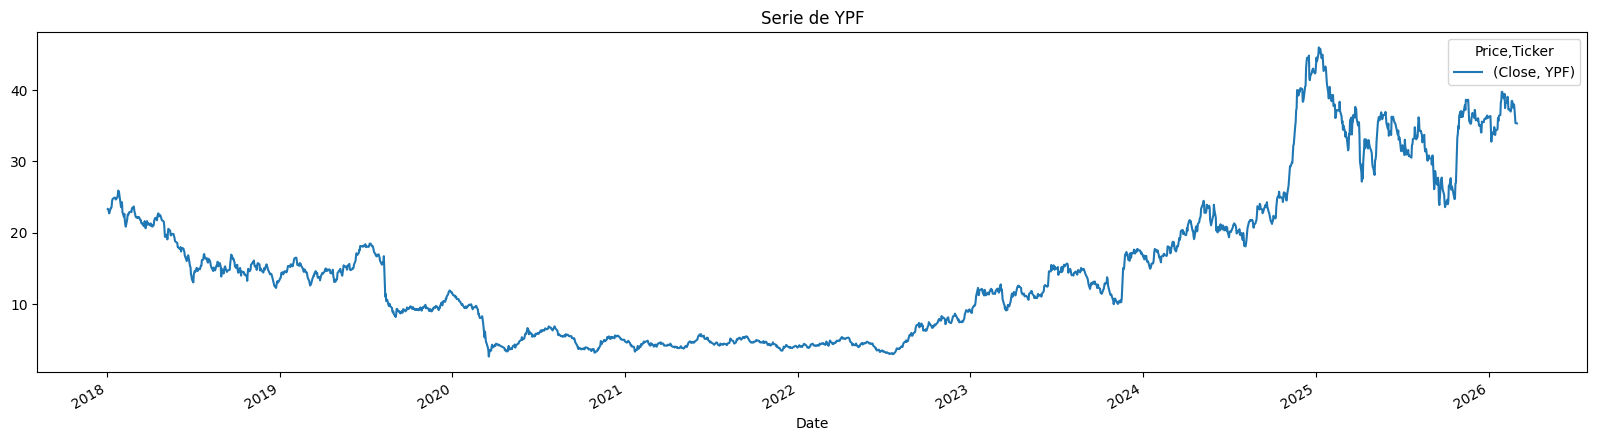

In [ ]:
data.plot(figsize=(20,5), title = "Serie de YPF")
plt.show()

En el grafico de arriba , teniendo en cuenta lo visto en la parte teorica. ¿ que ven ?

Justamente vemos un proceso "Random Walk" o "caminata aleatoria" , asi es como se comportan la gran parte de los datos de este tipo.

Con los modelos que vemos en estas primeras clases es dificil poder analizar este tipo de datos, en crudo sin ningun tipo de transformaciones. Pero en estas primeras clases saber como son los comportamientos nos sirven para poder entender los datos y que hacer o no hacer.

Lo que tambien lleva a otro comentario: Transformar variables para poder analizar bien los datos es algo que surge de la practica y es otro tema inicial importante que debemos considerar y podemos aplicar enseñanzas de otras materias, siempre y cuando respetemos la temporalidad de los datos.

Descomposición de Series Temporales.

Pueden ser aditivas o multiplicativas. Basicamente, hay que encontrar la forma en que mejor representemos los datos.  

In [ ]:
# Modulo para uso exclusivo aqui
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

Descomposicion multiplicativa

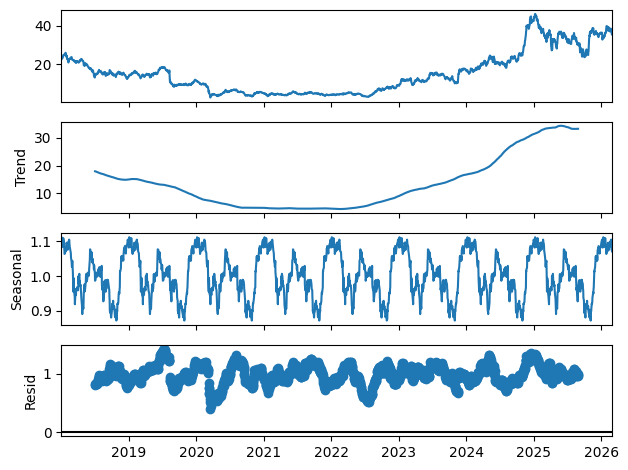

In [ ]:
# Realizar la descomposición estacional aditiva
result = seasonal_decompose(data['Close'], model='multiplicative', period=252)

'''
"period=252" indica un ciclo completo anual basado en los días hábiles del mercado, que se usa con frecuencia en series temporales financieras.
'''

# Graficar los resultados
result.plot()
plt.show()

Descomposicion Aditiva

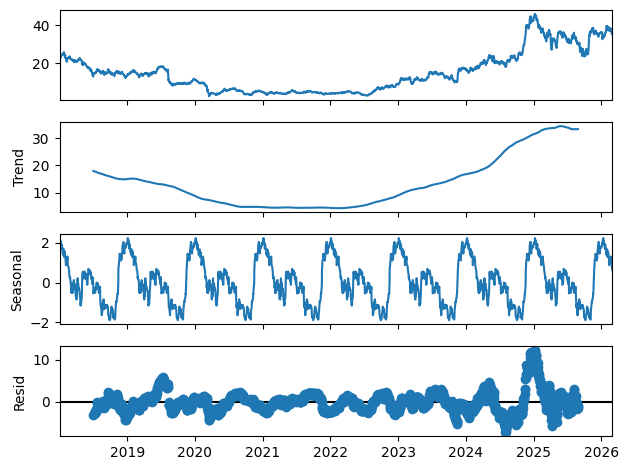

In [ ]:
# Realizar la descomposición estacional aditiva
result_A = seasonal_decompose(data['Close'], model='additive', period=252)

'''
"period=252" indica un ciclo completo anual basado en los días hábiles del mercado, que se usa con frecuencia en series temporales financieras.
'''

# Graficar los resultados
result_A.plot()
plt.show()

Con que modelo nos quedamos ?

Primero hay que tener en cuenta que estamos haciendo un primer analisis visual de los datos, donde quizas hay informacion que no llegamos a considerar porque escapa a nuestros ojos. De todas maneras hay algo interesante que se ve que podemos considerar :

Tomamos en este caso el modelo multiplicativo para realizar la descomposicion de las series.

En el modelo aditivo los residuos deberian oscilar alrededor de cero y presentar una variabilidad aproximadamente constante. Pero hacia el final de la serie se observa un aumento en la dispersion de los residuos lo que sugiere que la variabilidad depende del nivel de la serie. Esto mostraria q el modelo aditivo no captura adecuadamente la estructura de los datos.
El modelo multiplicativo seria mejor porque los residuos se mantienen centrados alrededor de 1 y muestran un comportamiento + estable a lo largo del tiempo.

Por ultimo, las fluctuaciones se vuelven mas grandess cuando el nivel de la serie es mayor. Esto tambien es un indicador que la serie se representa mas con un modelo multiplicativo.

Tambien podemos ver los componentes por separado

In [ ]:
trend = result.trend
seasonal = result.seasonal
resid = result.resid

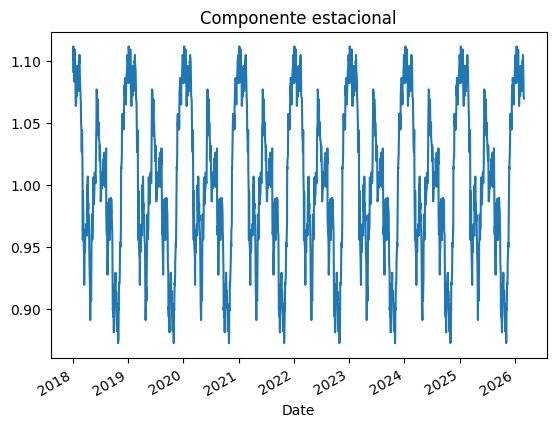

In [ ]:
seasonal.plot(title='Componente estacional')
plt.show()

Representación gráfica de la Función de Autocorrelación -  Aqui introducimos este grafico importante, recordar lo visto en la parte teorica y tb ver el ejercicio anexo 1 a este ejerccio

In [ ]:
# Modulo para uso exclusivo a partir de aqui
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import matplotlib

In [ ]:
matplotlib.rcParams['figure.figsize']=[6.0,4.0]

Grafico ACF del ejemplo en cuestion - YPF

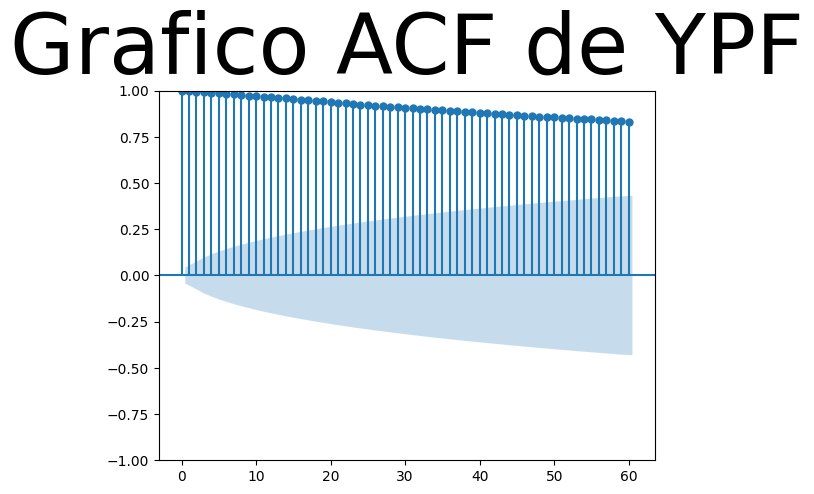

In [ ]:
plot_acf(data.Close,lags=60)
plt.title("Grafico ACF de YPF", size= 60)
plt.show()

# vemos datos no estacionarios

Pensar y contestarse, ¿ porque vemos aqui que los datos son no estacionarios?

APLICAMOS UNA TRANSFORMACION DE LA SERIE

In [ ]:

serie = data.Close.values.ravel()

primera_diffs = serie[1:] - serie[:-1]
primera_diffs = np.concatenate([primera_diffs, [0]])


In [ ]:
data['primera_diffs_spx']=primera_diffs

In [ ]:
data.head()

Price,Close,primera_diffs_spx
Ticker,YPF,
Date,,
2018-01-02,23.311460,-0.039442
2018-01-03,23.272018,-0.305693
2018-01-04,22.966326,-0.276110
2018-01-05,22.690216,0.729715
2018-01-08,23.419931,0.009861


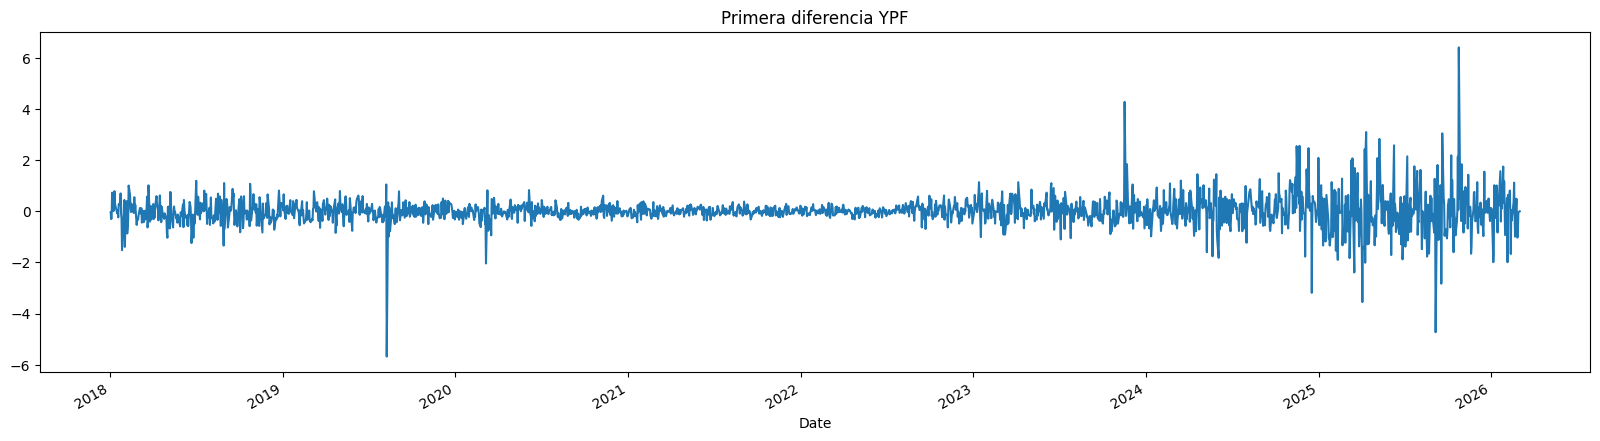

In [ ]:
#grafico este indice con las diferencias aplicadas fila a fila
data.primera_diffs_spx.plot(figsize=(20,5), title = "Primera diferencia YPF")
plt.show()

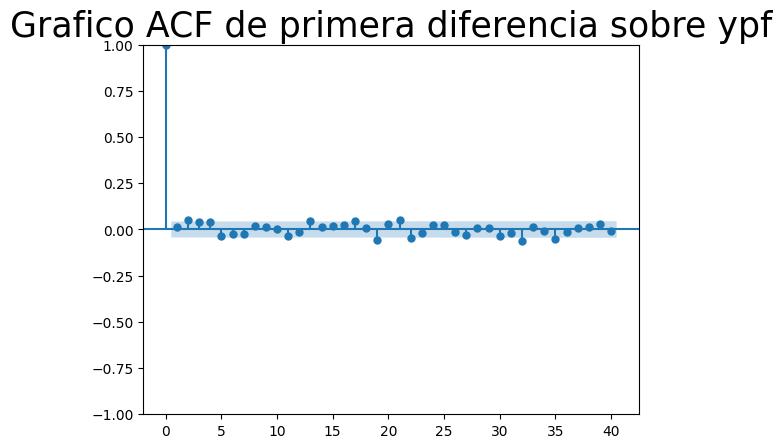

In [ ]:
#grafico este indice con las diferencias aplicadas fila a fila

plot_acf(data.primera_diffs_spx,lags=40)
plt.title("Grafico ACF de primera diferencia sobre ypf", size= 25)
plt.show()

¿ que vemos en este grafico ?
¿ que moelo teorico seria ?

#### Ruido Blanco

Simulación de ruido blanco
Aqui generamos una serie de valores aleatorios que siguen una distribución normal, con la misma media y desviación estándar que la serie temporal de precios ajustados. Aqui podemos tener propiedades similares a las de la serie exportada de yf.

In [ ]:
wn = np.random.normal(loc = data.Close.mean(), scale = data.Close.std(), size = len(data))
data['wn'] = wn
data.describe()

NameError: name 'np' is not defined

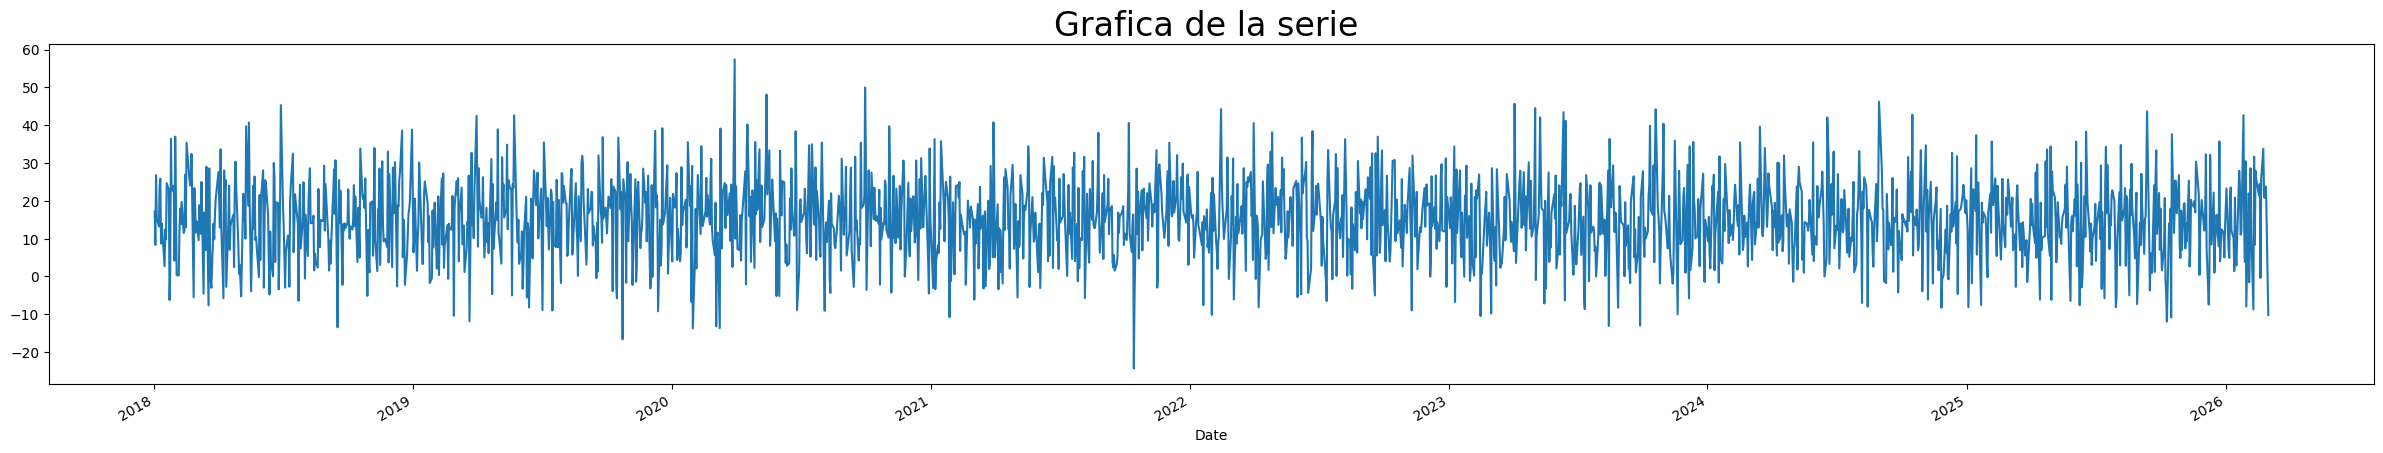

In [ ]:
data.wn.plot(figsize = (30,5))
plt.title("Grafica de la serie ", size= 24)
plt.show()

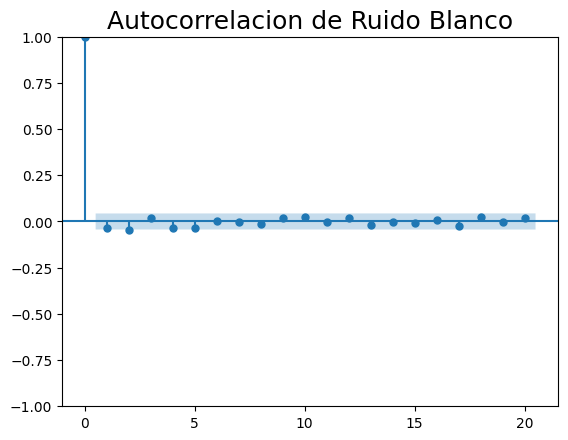

In [ ]:
plot_acf(data.wn, lags=20)
plt.title("Autocorrelacion de Ruido Blanco", size= 18)
plt.show()

#### Simulacion de un modelo Random Walk

Aqui vemos que los datos simulados tienen un comportamiento similar a los valores de YPF.

In [ ]:
# Simulamos el proceso
steps = np.random.standard_normal(1000)
steps[0]=0
random_walk=np.cumsum(steps)

In [ ]:
random_walk[:10]

array([0.        , 1.83180449, 1.8805679 , 2.24360006, 3.15583185,
       2.60346737, 0.62848977, 0.60824086, 1.32792336, 1.0047951 ])

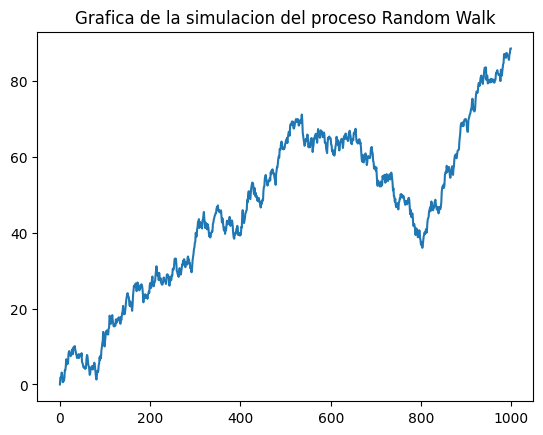

In [ ]:
plt.plot(random_walk)
plt.title("Grafica de la simulacion del proceso Random Walk")
plt.show()

In [ ]:
random_walk_acf_coef = acf(random_walk)
random_walk_acf_coef

array([1.        , 0.99679715, 0.99368686, 0.99056838, 0.98737448,
       0.98417286, 0.98084749, 0.97749303, 0.97397975, 0.97059745,
       0.96721272, 0.96409837, 0.96094808, 0.95768178, 0.9544243 ,
       0.95116777, 0.94785685, 0.9447926 , 0.94175934, 0.93871254,
       0.93588511, 0.93309635, 0.93028916, 0.927545  , 0.92456387,
       0.92162224, 0.91866027, 0.91560436, 0.9126265 , 0.90949204,
       0.90632344])

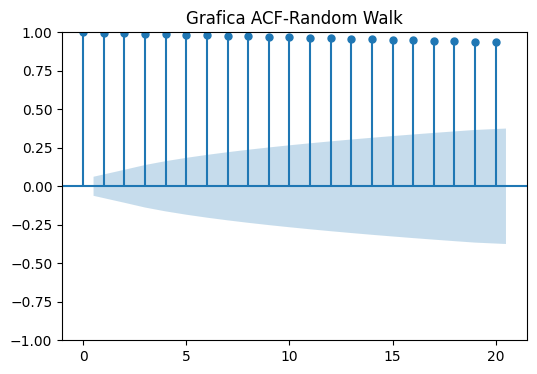

In [ ]:
plot_acf(random_walk, lags=20)
plt.title("Grafica ACF-Random Walk")
plt.show()

Aqui tambien vemos que la serie es NO ESTACIONARIA.

Porque esta afirmacion ?

Como comentario extra, tengan en cuenta que el comportamiento ruido blanco es el comportamiento esperado cuando analizaremos los residuos de los modelos. Por ello es importante este ejercicio . Conocer los comportamientos y saber con que nos podemos encontrar.

El fin de este ejercicio es que puedan analizarlo, repasar la teoria y aplicar lo aprendido en este ejercicio.

Obviamente, cualquier comentario o duda nos pueden escribir por el foro.


- Como comentario extra, por fuera de este trabajo. Hagan el log de los precios y vuelvan a analizar la serie para saber como les da. Como les comentamos las transoformaciones de las series son importantes y mas para poder trabajar estos primeros modelos.

<body>
  <h1> Muchas gracias! 😀</h1>
</body>